In [1]:
from sklearn import set_config
set_config(transform_output="pandas")

In [2]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [63]:
diabetes = pd.read_csv("Documents/MAchine Learning/ML Datasets/diabetis_risk_db/diabetes_risk.csv")

In [64]:
diabetes.head(5)

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [65]:
diabetes.shape

(15000, 19)

In [66]:
diabetes.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  str    
 3   city                      15000 non-null  str    
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  str    
 6   physical_activity_level   15000 non-null  str    
 7   diet_type                 15000 non-null  str    
 8   smoking_status            14528 non-null  str    
 9   alcohol_consumption       11212 non-null  str    
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_pressure_sy

In [67]:
diabetes.describe()

,patient_id,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,44.333667,23.062260,7.309860,5.941200,168.789933,6.878387,139.496200,86.256933,100.207933
std,4330.271354,10.383753,4.046391,1.109372,2.148406,38.365822,0.843276,12.660785,8.386529,10.760331
min,1.000000,18.000000,15.000000,3.000000,1.000000,72.000000,4.800000,80.000000,50.000000,73.200000
25%,3750.750000,38.000000,20.100000,6.700000,4.000000,145.000000,6.300000,130.000000,80.000000,92.500000
50%,7500.500000,45.000000,22.700000,7.000000,6.000000,165.000000,6.800000,140.000000,88.000000,99.300000
75%,11250.250000,52.000000,25.600000,8.000000,7.000000,189.000000,7.300000,150.000000,90.000000,106.900000
max,15000.000000,80.000000,40.800000,12.000000,10.000000,400.000000,13.400000,200.000000,120.000000,148.200000


In [68]:
# Merge Moderate into High -> creates a binary target: Low vs Elevated (Moderate+High)
diabetes['diabetes_risk_binary'] = diabetes['diabetes_risk'].replace({
    'Moderate': 'Elevated',
    'High': 'Elevated',
    'Low': 'Low'
})

print(diabetes['diabetes_risk_binary'].value_counts())

diabetes_risk_binary
Low         9000
Elevated    6000
Name: count, dtype: int64


In [69]:
diabetes

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk,diabetes_risk_binary
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High,Elevated
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14996,47,Male,Mumbai,37.7,No,Sedentary,Non-Vegetarian,Never,Never,6.8,7,213,8.1,150,100,141.7,High,High,Elevated
14996,14997,48,Female,Mumbai,20.6,No,Moderate,Non-Vegetarian,Never,NaN,6.0,8,162,6.5,132,80,91.0,NaN,Low,Low
14997,14998,34,Female,Nagpur,17.9,No,Active,Vegetarian,Never,Never,7.0,6,137,6.5,136,90,88.8,Low,Low,Low
14998,14999,56,Male,Ahmedabad,20.7,Yes,Active,Vegetarian,Never,Never,6.0,5,163,6.9,140,87,94.8,Low,Low,Low


In [70]:
diabetes=diabetes.drop(columns=["patient_id", "city", "income_bracket", "diabetes_risk"])

In [71]:
diabetes

,age,gender,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,diabetes_risk_binary
0,47,Female,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,Low
1,53,Female,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low
2,47,Male,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Elevated
3,41,Male,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Low
4,57,Female,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,47,Male,37.7,No,Sedentary,Non-Vegetarian,Never,Never,6.8,7,213,8.1,150,100,141.7,Elevated
14996,48,Female,20.6,No,Moderate,Non-Vegetarian,Never,NaN,6.0,8,162,6.5,132,80,91.0,Low
14997,34,Female,17.9,No,Active,Vegetarian,Never,Never,7.0,6,137,6.5,136,90,88.8,Low
14998,56,Male,20.7,Yes,Active,Vegetarian,Never,Never,6.0,5,163,6.9,140,87,94.8,Low


In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='count', ylabel='gender'>

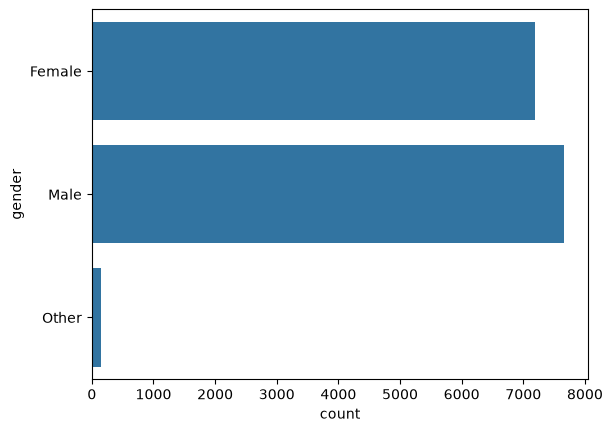

In [73]:
sns.countplot(diabetes["gender"])

In [74]:
diabetes['gender'].value_counts()

gender
Male      7664
Female    7183
Other      153
Name: count, dtype: int64

In [75]:
#remove other gender rows
Other_gender_rows=diabetes[diabetes["gender"]=='Other'].index
diabetes = diabetes.drop(Other_gender_rows)
diabetes['gender'].value_counts()


gender
Male      7664
Female    7183
Name: count, dtype: int64

In [76]:
columns=["age","bmi","hours_sleep_per_night","stress_level","fasting_blood_sugar","hba1c_level","blood_pressure_systolic","blood_pressure_diastolic","waist_circumference_cm"] 

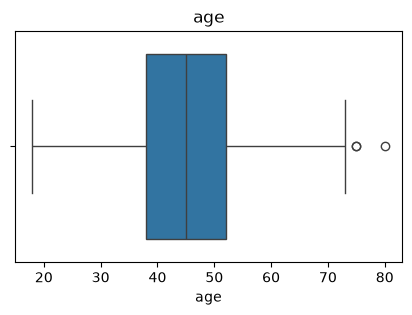

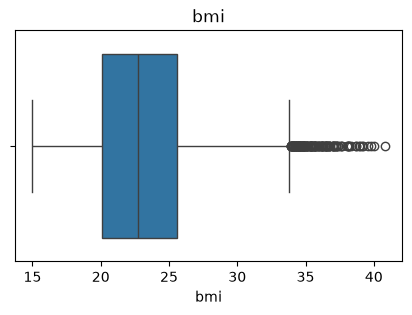

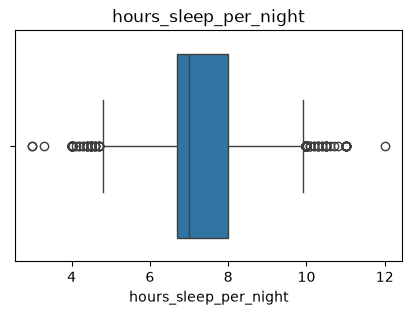

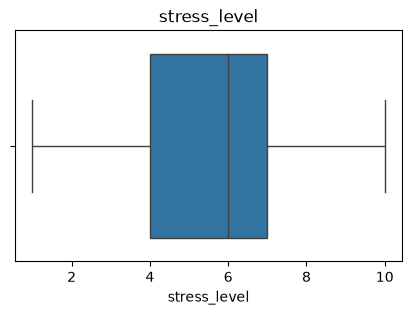

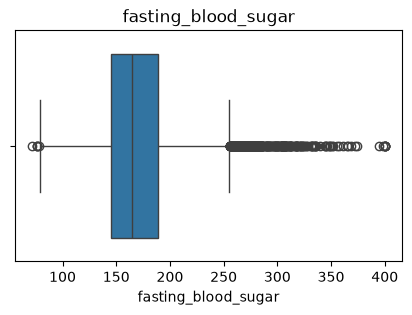

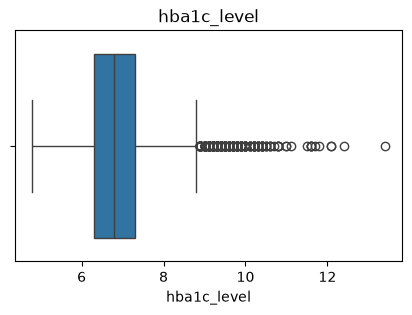

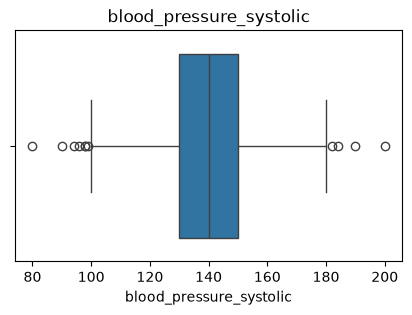

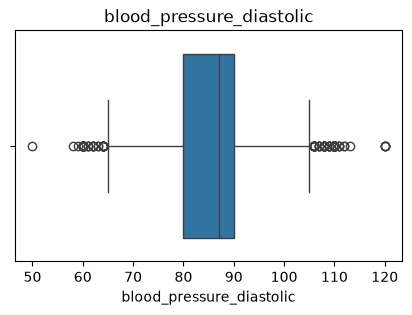

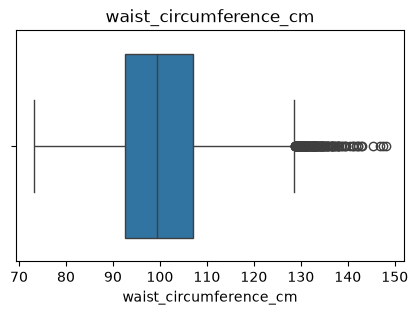

In [77]:
#outlier detection
for col in columns:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x=diabetes[col])
    plt.title(col)
    plt.show()

In [78]:
#missing value 
diabetes.isnull().mean()*100

age                          0.000000
gender                       0.000000
bmi                          0.000000
family_history_diabetes      0.000000
physical_activity_level      0.000000
diet_type                    0.000000
smoking_status               3.125210
alcohol_consumption         25.331717
hours_sleep_per_night        0.000000
stress_level                 0.000000
fasting_blood_sugar          0.000000
hba1c_level                  0.000000
blood_pressure_systolic      0.000000
blood_pressure_diastolic     0.000000
waist_circumference_cm       0.000000
diabetes_risk_binary         0.000000
dtype: float64

In [79]:
X = diabetes.drop("diabetes_risk_binary",axis=1)
Y=diabetes["diabetes_risk_binary"]

In [80]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
print(f"X_train shape : {x_train.shape}")
print(f"X_test shape : {x_test.shape}")

X_train shape : (11877, 15)
X_test shape : (2970, 15)


In [81]:
y_train

3717          Low
9456          Low
3682          Low
7103          Low
3124     Elevated
           ...   
5687          Low
438           Low
12533         Low
7811          Low
5271          Low
Name: diabetes_risk_binary, Length: 11877, dtype: str

In [82]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [84]:
from sklearn.pipeline import Pipeline
smoking_pipeline= Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=[["Never", "Former", "Current"]]))
])

alcohol_pipeline= Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Never")),
    ("encoder", OrdinalEncoder(categories=[["Never", "Occasional", "Regular"]]))
])

onehot_pipeline= Pipeline([
    ("encoder", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"))
])

activity_pipeline = Pipeline([
    ("encoder", OrdinalEncoder(categories=[["Sedentary", "Moderate", "Active"]]))
])

family_pipeline= Pipeline([
    ("encoder", OrdinalEncoder(categories=[["No", "Yes"]]))
])


In [85]:
preprocessor = ColumnTransformer([
    ("Smoking",smoking_pipeline, ["smoking_status"]),
    ("alcohol", alcohol_pipeline, ["alcohol_consumption"]),
    ("onehot", onehot_pipeline, ["gender", "diet_type"]),
    ("activity", activity_pipeline, ["physical_activity_level"]),
    ("family", family_pipeline, ["family_history_diabetes"]),
    ("scaling", StandardScaler(), columns)
])

In [88]:
from sklearn.ensemble import RandomForestClassifier

full_pipe_rf=Pipeline([
    ("preprocessing", preprocessor),
    ("model",RandomForestClassifier(random_state=42))
])

In [89]:
from sklearn.model_selection import GridSearchCV
param_grid_rf={
    "model__n_estimators":[100, 200, 500],
    "model__max_depth": [5, 10, 15, None],
    "model__min_samples_split": [2, 5, 10]
}


grid_rf = GridSearchCV(full_pipe_rf, param_grid_rf, cv=5, scoring="recall")
grid_rf.fit(x_train, y_train_enc)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose 

In [109]:
y_pred_rf= grid_rf.best_estimator_.predict(x_test)

In [112]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test_enc,y_pred_rf, target_names=le.classes_)) 

              precision    recall  f1-score   support

    Elevated       0.83      0.78      0.80      1188
         Low       0.86      0.90      0.88      1782

    accuracy                           0.85      2970
   macro avg       0.85      0.84      0.84      2970
weighted avg       0.85      0.85      0.85      2970



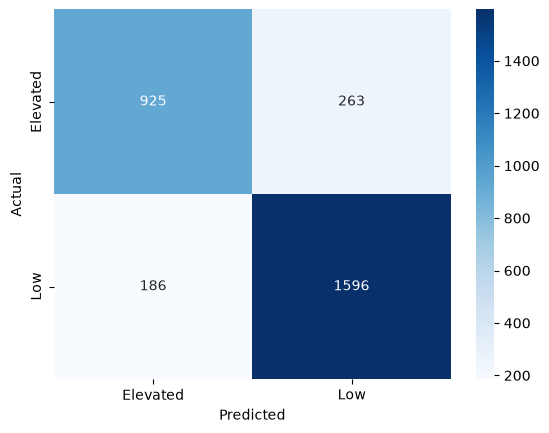

In [113]:
cm = confusion_matrix(y_test_enc, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [114]:
from sklearn.linear_model import LogisticRegression

full_pipe_lr=Pipeline([
    ("Preprocessing", preprocessor),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])

param_grid_lr={
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty":["l1", "l2"],
    "model__solver": ["liblinear"],  
    "model__class_weight": ["balanced", None]
}

grid_lr=GridSearchCV(full_pipe_lr, param_grid_lr, cv=5, scoring="recall")
grid_lr.fit(x_train, y_train_enc)


C:\Users\adity\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\adity\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\adity\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': ['balanced', None], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable a

In [117]:
y_pred_lr=grid_lr.best_estimator_.predict(x_test)

In [118]:
print(classification_report(y_test_enc, y_pred_lr, target_names=le.classes_ ))

              precision    recall  f1-score   support

    Elevated       0.83      0.80      0.82      1188
         Low       0.87      0.89      0.88      1782

    accuracy                           0.86      2970
   macro avg       0.85      0.85      0.85      2970
weighted avg       0.86      0.86      0.86      2970



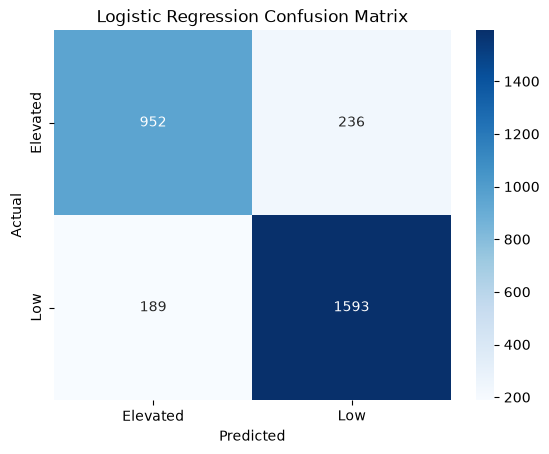

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test_enc, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [120]:
from sklearn.tree import DecisionTreeClassifier

full_pipe_dt=Pipeline([
    ("Preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

param_grid_dt={
    "model__max_depth": [3, 5, 10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__criterion": ["gini", "entropy"],
    "model__class_weight": ["balanced", None]
}

grid_dt=GridSearchCV(full_pipe_dt, param_grid_dt, cv=5, scoring="recall")
grid_dt.fit(x_train, y_train_enc)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': ['balanced', None], 'model__criterion': ['gini', 'entropy'], 'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.

In [121]:
y_pred_dt = grid_dt.best_estimator_.predict(x_test)

In [122]:
print(classification_report(y_test_enc, y_pred_dt, target_names=le.classes_))

              precision    recall  f1-score   support

    Elevated       0.86      0.69      0.76      1188
         Low       0.82      0.93      0.87      1782

    accuracy                           0.83      2970
   macro avg       0.84      0.81      0.82      2970
weighted avg       0.83      0.83      0.83      2970



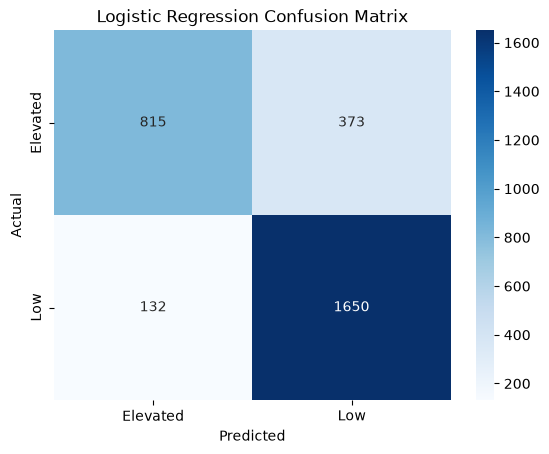

In [123]:
cm_dt = confusion_matrix(y_test_enc, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [125]:
#Logistic Regression Model wins 

In [ ]:
import pickle
 
with open("diabetes_risk_model.pkl", "wb") as f:
    pickle.dump(grid_lr.best_estimator_, f)
 
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
 
print("Saved diabetes_risk_model.pkl and label_encoder.pkl")
print("Label classes:", le.classes_)  
 
input_columns = list(x_train.columns)
with open("input_columns.pkl", "wb") as f:
    pickle.dump(input_columns, f)
 
print("Input columns expected by the model:")
print(input_columns)

Saved diabetes_risk_model.pkl and label_encoder.pkl
Label classes: ['Elevated' 'Low']
Input columns expected by the model:
['age', 'gender', 'bmi', 'family_history_diabetes', 'physical_activity_level', 'diet_type', 'smoking_status', 'alcohol_consumption', 'hours_sleep_per_night', 'stress_level', 'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'waist_circumference_cm']
